In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
water,18.02,1.2047,2.801457,353.94,1,1
ethylamine,45.09,2.744,3.1134,216.82,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,ethylamine,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethylamine,H,ethylamine,e,560.29,0.1338
water,H,water,e,2425.67,0.045
ethylamine,H,water,e,1492.98,0.077487
ethylamine,e,water,H,1492.98,0.077487
"""

model = PCSAFT(["water", "ethylamine"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[353.94 279.7923700587276; 279.7923700587276 216.82]
[2.8014570000000003e-10 2.9574285000000003e-10; 2.9574285000000003e-10 3.1134e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_water::Float64)
    P = 93300 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    T = bub[1]
    y = bub[4][1]
    return T
end

function vle_y(model::EoSModel, x_water::Float64)
    P = 93300 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [7]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 250.,
        :upper   => 350.0,
        :guess   => 279.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 350.0, :param => :epsilon, :indices => (1, 2), :guess => 279.0, :lower => 250.0)

In [8]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_ethylamine.csv")
fix_line_endings("vley_ethylamine.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_ethylamine.csv"
        "vley_ethylamine.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_ethylamine.csv
Fixed: vley_ethylamine.csv
Initial objective value: 0.5877207920642885


In [9]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([307.90519270537334], PCSAFT{BasicIdeal, Float64}("water", "ethylamine"))

In [10]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[353.94 307.90519270537334; 307.90519270537334 216.82]
[2.8014570000000003e-10 2.9574285000000003e-10; 2.9574285000000003e-10 3.1134e-10]
kij = -0.11148222007323638


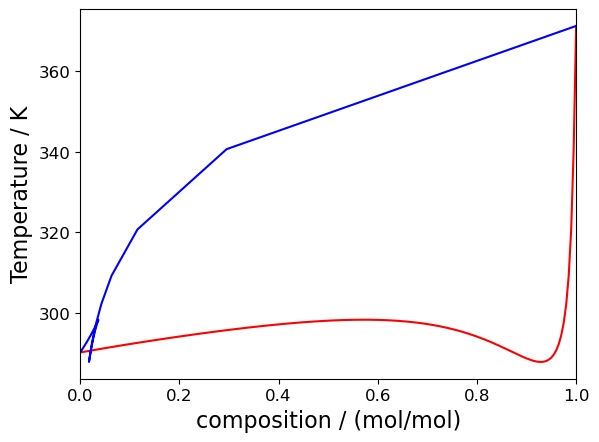

([280.0, 300.0, 320.0, 340.0, 360.0, 380.0], PyCall.PyObject[PyObject Text(0, 280.0, '280'), PyObject Text(0, 300.0, '300'), PyObject Text(0, 320.0, '320'), PyObject Text(0, 340.0, '340'), PyObject Text(0, 360.0, '360'), PyObject Text(0, 380.0, '380')])

In [12]:
import PyPlot; const plt = PyPlot
using Clapeyron

N    = 201
p    = 93300

x    = LinRange(0., 1.,  N)
T    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_temperature(model, p, [x[i], 1-x[i]])
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_temperature(model, p, [x[i], 1-x[i]]; v0 = v0)
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

plt.clf()
plt.plot(x, T, color="red")
plt.plot(y, T, color="blue")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Temperature / K",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [13]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [14]:
aard_p   = calculate_AAD(model_opt, "vlep_ethylamine.csv", vle_p)


=== AAD: vlep_ethylamine.csv ===

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



Clapeyron Estimator  exp           calc          ARD%    
0.1000      290.839400    292.522133    0.5786  
0.2000      293.737800    294.781291    0.3552  
0.3000      297.536200    297.146866    0.1309  
0.4000      302.934100    299.805875    1.0326  
0.5000      308.731800    303.026818    1.8479  
0.6000      315.129400    307.258814    2.4976  
0.7000      323.626900    313.350746    3.1753  
0.8000      333.124000    323.114143    3.0048  
0.9000      343.524000    340.736352    0.8115  
0.9500      354.323000    354.613266    0.0819  
AARD = 1.3516%


1.351632747231976

In [15]:
aard_p   = calculate_AAD(model_opt, "vley_ethylamine.csv", vle_y)


=== AAD: vley_ethylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1000      0.005000      0.004008      19.8357 
0.2000      0.012000      0.007933      33.8876 
0.3000      0.023000      0.012215      46.8923 
0.4000      0.039000      0.017402      55.3792 
0.5000      0.058000      0.024454      57.8372 
0.6000      0.088000      0.035435      59.7324 
0.7000      0.144000      0.055760      61.2781 
0.8000      0.224000      0.103699      53.7059 
0.9000      0.342000      0.265898      22.2520 
0.9500      0.572000      0.504498      11.8011 
AARD = 42.2601%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


42.26014107163245